# NLP Course 1 - Week 2 Alternative Assignment

## Movie Review Sentiment Analysis with Naive Bayes

---

## Assignment Overview

**Your Mission**: Build a **Naive Bayes classifier** for movie review sentiment analysis from scratch. This week, you'll learn a fundamentally different approach than logistic regression - one based on probabilistic reasoning and word frequency counting, with NO gradient descent!

**Key Difference from Week 1**:

- **No iterative training** - just count and calculate probabilities
- **No gradient descent** - training happens in a single pass
- **Probabilistic reasoning** - using Bayes' theorem instead of sigmoid activation
- **Faster training** - orders of magnitude faster than logistic regression
- **Different feature representation** - using word frequencies differently

**Expected Time**: 5-7 hours

**Difficulty**: Intermediate to Advanced (with gotchas 😈)

## Learning Objectives

By completing this assignment, you will demonstrate mastery of:

1. **Probability Theory** - Understanding conditional probability and Bayes' rule
2. **Frequency Counting** - Building word-class frequency dictionaries
3. **Laplacian Smoothing** - Handling zero probabilities elegantly
4. **Log Likelihood Calculation** - Avoiding numerical underflow
5. **Log Prior Computation** - Handling class imbalance
6. **Naive Bayes Training** - Non-iterative parameter estimation
7. **Probabilistic Classification** - Making predictions using likelihood ratios
8. **Error Analysis** - Understanding model assumptions and failures

## Core Concept: What Makes Naive Bayes Different?

### Logistic Regression (Week 1) vs Naive Bayes (Week 2)

```
LOGISTIC REGRESSION:
- Features: [1, sum_pos_freq, sum_neg_freq] → 3 numbers per review
- Training: Gradient descent (1500 iterations)
- Parameters: θ = [θ₀, θ₁, θ₂] → 3 weights
- Prediction: sigmoid(θᵀx) → probability

NAIVE BAYES:
- Features: Individual word presence/absence
- Training: Count frequencies (1 pass through data)
- Parameters: P(word|class) for each word → thousands of probabilities
- Prediction: ∏ P(word|class) → product of probabilities
```

### The "Naive" Assumption

Naive Bayes assumes words are **independent** of each other:

```
P("love" and "great" | positive) ≈ P("love" | positive) × P("great" | positive)
```

This is "naive" because words clearly depend on each other, but it works surprisingly well!

## Dataset Specification

**Use the same movie review dataset from Week 1**:

**Important**: You should already have this from Week 1. If not, refer to Week 1 assignment for dataset acquisition.

### Dataset: IMDB Movie Reviews (Simplified Version)

**Source**: You'll need to create or download a simplified version

**Size**: 2000 reviews (1000 positive + 1000 negative)

**Format**: Two text files or a CSV with columns: `review_text`, `sentiment`

### Dataset Structure

```
reviews.csv
├── review: "This movie was absolutely fantastic! The acting was superb..."
└── sentiment: (1 or positive) or (0 or negative)
```

I downloaded the data from https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/data and renamed the file as reviews.csv

### Setup and imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import defaultdict
import random
from typing import List, Dict, Tuple, Set
from sklearn.model_selection import train_test_split
import string  

import nltk
# download the stopwords from NLTK
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

[nltk_data] Error loading stopwords: <urlopen error [Errno -3]
[nltk_data]     Temporary failure in name resolution>


### Data preparation

In [2]:
# read the csv
data  = pd.read_csv("../data/reviews.csv");

print("Data shape ", data.shape)
print("Total data length ", data.shape[0])

# print the first 5 data
data.head(5)

Data shape  (50000, 2)
Total data length  50000


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
# features and labels
X = data['review'].values
Y = data["sentiment"].values

# X = data['review'].values[:1000]
# Y = data["sentiment"].values[:1000]

# print the shape of X and Y
print("X data : ",X[:2])
print("Y data ",Y[:2])

print("X shape : ",X.shape)
print("Y shape : ",Y.shape)

X data :  ["One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is du

In [4]:
print("BEFORE TRANSFORMATION")
print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")
print(f"X dtype: {X.dtype}")
print(f"Y dtype: {Y.dtype}")
print(f"\nFirst review (X[0]):\n{X[0][:200]}...")
print(f"\nFirst label (Y[0]): {Y[0]}")
print(f"Second label (Y[1]): {Y[1]}")

# Convert Labels to Numeric
# Convert 'positive'/'negative' strings to 1/0 integers
Y_numeric = np.array([1 if label == 'positive' else 0 for label in Y])

print("\nAFTER LABEL CONVERSION")
print(f"Y_numeric shape: {Y_numeric.shape}")
print(f"Y_numeric dtype: {Y_numeric.dtype}")
print(f"First 5 labels: {Y_numeric[:5]}")
print(f"Unique values: {np.unique(Y_numeric)}")

# Train/Test Split (80/20)
X_train, X_test, Y_train, Y_test = train_test_split(
    X,                   
    Y_numeric,          
    test_size=0.2,
    random_state=42,
    stratify=Y_numeric   # Maintains class balance
)


# FINAL VERIFICATION
print("\nWEEK 2 DATA PREPARATION - FINAL FORMAT")
print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"Y_test shape:  {Y_test.shape}")

print(f"\nX_train dtype: {X_train.dtype}")
print(f"Y_train dtype: {Y_train.dtype}")

print("SAMPLE DATA (First 2 examples)")
print(f"\nTrain X[0] (first 150 chars):\n{X_train[0][:150]}...")
print(f"Train Y[0]: {Y_train[0]}")
print(f"\nTrain X[1] (first 150 chars):\n{X_train[1][:150]}...")
print(f"Train Y[1]: {Y_train[1]}")

print("\n" + "-"*60)
print("CLASS DISTRIBUTION")
print(f"Positive samples in train: {np.sum(Y_train == 1)} ({np.sum(Y_train == 1)/len(Y_train)*100:.1f}%)")
print(f"Negative samples in train: {np.sum(Y_train == 0)} ({np.sum(Y_train == 0)/len(Y_train)*100:.1f}%)")
print(f"Positive samples in test:  {np.sum(Y_test == 1)} ({np.sum(Y_test == 1)/len(Y_test)*100:.1f}%)")
print(f"Negative samples in test:  {np.sum(Y_test == 0)} ({np.sum(Y_test == 0)/len(Y_test)*100:.1f}%)")

print("\nDATA READY FOR WEEK 2 NAIVE BAYES!")

BEFORE TRANSFORMATION
X shape: (50000,)
Y shape: (50000,)
X dtype: object
Y dtype: object

First review (X[0]):
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo...

First label (Y[0]): positive
Second label (Y[1]): positive

AFTER LABEL CONVERSION
Y_numeric shape: (50000,)
Y_numeric dtype: int64
First 5 labels: [1 1 1 0 1]
Unique values: [0 1]

WEEK 2 DATA PREPARATION - FINAL FORMAT

X_train shape: (40000,)
X_test shape:  (10000,)
Y_train shape: (40000,)
Y_test shape:  (10000,)

X_train dtype: object
Y_train dtype: int64
SAMPLE DATA (First 2 examples)

Train X[0] (first 150 chars):
I caught this little gem totally by accident back in 1980 or '81. I was at a revival theatre to see two old silly sci-fi movies. The theatre was packe...
Train Y[0]: 1

Train X[1] (first 150 chars):
I can't believe that I let myself into this movie to accompl

In [5]:
train_reviews = X_train
train_labels = Y_train
test_reviews = X_test
test_labels = Y_test

print("ALIAS VARIABLES CREATED")
print(f"train_reviews shape: {train_reviews.shape}")
print(f"train_labels shape: {train_labels.shape}")
print(f"test_reviews shape: {test_reviews.shape}")
print(f"test_labels shape: {test_labels.shape}")

ALIAS VARIABLES CREATED
train_reviews shape: (40000,)
train_labels shape: (40000,)
test_reviews shape: (10000,)
test_labels shape: (10000,)


### Util functions from week 1

In [6]:
# text preprocessing function
def process_review(review_text: str) -> List[str]:
    """
    Complete preprocessing pipeline for review

    Args:
        review_text: Raw review string

    Returns:
        processed_words: List of cleaned words
    """

    # Convert to lowercase
    review_text = review_text.lower()


    # Remove URLs (movie reviews might have them)
    review_text = re.sub(r'https?://[^\s\n\r]+', '', review_text)

    # Remove HTML tags (e.g., `<br />`)
    review_text = re.sub(r'<.*?>', '', review_text)

    # Remove punctuation (replace with space)
    review_text = re.sub(r'[^\w\s]', ' ', review_text)

    stopwords_english_set = set(stopwords.words('english'))

    # Keep negation words
    negations = {
        'not', 'no', 'nor', 'neither', 'never', 
        'none', 'nobody', 'nothing', 'nowhere',
        'wasn', 't', 'don', 'doesn', 'didn',
        'won', 'wouldn', 'shouldn', 'couldn',
        'hasn', 'haven', 'isn', 'aren', 'ain',
        'weren', 'hadn', 'mightn', 'mustn',
        'needn', 'shan'
    }
    stopwords_english_set = stopwords_english_set - negations
    

    stemmer = PorterStemmer()

    review_clean = []

    #  Tokenize into words
    word_list = review_text.split()

    for word in word_list:
       # Skip empty strings and stopwords
        if word and word not in stopwords_english_set:
            # Apply stemming
            stem_word = stemmer.stem(word)
            review_clean.append(stem_word)

    return review_clean            

## Part 1: Understanding Probability Foundations

### Milestone 1.1: Implement Word-Class Frequency Counter

**What to implement**: Create `count_words(reviews, labels)` function

**⚠️ GOTCHA #1**: Don't confuse this with Week 1's build_freqs!

- Week 1: We summed ALL frequencies for a review to get 2 numbers
- Week 2: We keep EACH word's frequency separately
- Week 1 output: 3 features per review
- Week 2 output: Thousands of (word, class) pairs

**Algorithm:**

```
1. Initialize empty dictionary freqs = {}
2. For each (review, label) pair:
    a. Preprocess the review (use your process_review from Week 1)
    b. For each word in processed review:
        - Create key = (word, label)
        - If key exists in freqs: increment count
        - Else: add key with count = 1
3. Return freqs
```

**💡 Hints**:

- Reuse your `process_review()` function from Week 1
- Use `zip(reviews, labels)` to iterate
- Use `.get((word, label), 0)` for safe dictionary access


**🎓 Concepts from Week 2 Material**:

- Naive Bayes introduction (Section 3)
- Frequency counting for classification
- Building vocabulary with class labels

In [7]:
def count_words(reviews, labels):
    """
    Count frequency of each (word, class) pair

    Args:
        reviews: list of review texts (strings)
        labels: list of labels (1 for positive, 0 for negative)

    Returns:
        freqs: dictionary where
               key = (word, label) tuple
               value = frequency count

    Example output:
        {
            ('great', 1): 234,
            ('great', 0): 45,
            ('terrible', 1): 12,
            ('terrible', 0): 189,
            ...
        }
    """
    freqs = {}

    # print("reviews : ", reviews[:2])
    # print("labels : ",labels[:2])

    for review, label in zip(reviews, labels):

        # Convert numpy int to Python int
        label = int(label)
        
        # print("review: ",review)
        # print("label : ",label)
        processed_review_words = process_review(review)

        for word in processed_review_words:
            key = (word, label)

            # print("label : ",label)
            # print("key : ",key)
            # print("freqs.get(key,0) : ",freqs.get(key,0))

            freqs[key] = freqs.get(key,0) + 1
    
    # print("freqs in end : ",freqs)

    return freqs

        

**Test your function:**


In [8]:
test_reviews_subset = [
    "This movie was great and really amazing",
    "Terrible film, very bad",
    "Amazing movie, great acting",
    "Bad movie, terrible acting"
]
test_labels_subset = [1, 0, 1, 0]

freqs = count_words(test_reviews_subset, test_labels_subset)

# Positive class (label = 1)
assert freqs.get(('movi', 1), 0) == 2, "Expected 'movi' to appear twice in positive reviews"
assert freqs.get(('great', 1), 0) == 2, "Expected 'great' to appear twice in positive reviews"
assert freqs.get(('amaz', 1), 0) == 2, "Expected 'amaz' to appear twice in positive reviews"
assert freqs.get(('act', 1), 0) == 1, "Expected 'act' once in positive reviews"

# Negative class (label = 0)
assert freqs.get(('bad', 0), 0) == 2, "Expected 'bad' to appear twice in negative reviews"
assert freqs.get(('terribl', 0), 0) == 2, "Expected 'terribl' to appear twice in negative reviews"
assert freqs.get(('film', 0), 0) == 1, "Expected 'film' once in negative reviews"
assert freqs.get(('act', 0), 0) == 1, "Expected 'act' once in negative reviews"

# Cross-check that positive and negative keys are distinct
assert ('great', 0) not in freqs, "Word 'great' should not appear in negative class"
assert ('terribl', 1) not in freqs, "Word 'terribl' should not appear in positive class"

print("count_words() test passed")
print(f"Total unique (word, class) pairs: {len(freqs)}")
for k, v in sorted(freqs.items()):
    print(f"{k}: {v}")


count_words() test passed
Total unique (word, class) pairs: 10
('act', 0): 1
('act', 1): 1
('amaz', 1): 2
('bad', 0): 2
('film', 0): 1
('great', 1): 2
('movi', 0): 1
('movi', 1): 2
('realli', 1): 1
('terribl', 0): 2


### Milestone 1.2: Calculate Class Statistics

**What to implement**: Create `get_class_stats(freqs)` function

**⚠️ GOTCHA #2**: Vocabulary size V is tricky!

- V = number of **unique words**, not total word count
- A word that appears in both classes counts as **1** word, not 2
- Example: If "movie" appears in both positive and negative, V counts it once

**Algorithm:**

```
1. N_pos = sum of all frequencies where label = 1
2. N_neg = sum of all frequencies where label = 0
3. V = number of unique words (extract words from keys, use set())
4. Return as dictionary
```

**Example calculation:**

```python
freqs = {
    ('love', 1): 50,
    ('love', 0): 5,
    ('hate', 1): 2,
    ('hate', 0): 60,
    ('movie', 1): 100,
    ('movie', 0): 95
}

# N_pos = 50 + 2 + 100 = 152
# N_neg = 5 + 60 + 95 = 160
# V = 3 (love, hate, movie - each counted once)
```

**💡 Hints**:

- Use list comprehension with conditions: `[v for (w, l), v in freqs.items() if l == 1]`
- Extract unique words: `set([word for (word, label) in freqs.keys()])`
- Sum frequencies: `sum(freqs.values())`

**🎓 Concepts from Week 2 Material**:

- Vocabulary extraction (Section 3)
- Class word counts for probability calculation
- Dataset statistics


In [9]:
def get_class_stats(freqs, labels):
    """
    Calculate statistics about each class

    Args:
        freqs: frequency dictionary from count_words()

    Returns:
        stats: dictionary with keys:
               'N_pos': total words in positive class
               'N_neg': total words in negative class
               'V': vocabulary size (unique words across all classes)
               'D_pos': number of positive reviews
               'D_neg': number of negative reviews
    """

    unique_words = set()

    N_pos = N_neg = 0

    for (word, label), count in freqs.items():

        if label==1:
            N_pos += count
        else:
            N_neg += count

        unique_words.add(word)

    D_pos = sum(1 for l in labels if l == 1)
    D_neg = sum(1 for l in labels if l == 0)

    res = {
        "N_pos" : N_pos,
        "N_neg" : N_neg,
        "V" : len(unique_words),
        "D_pos" : D_pos,
        "D_neg" : D_neg
    }

    print("res : ",res)

    return res


    

**Test your function:**

In [10]:
stats = get_class_stats(freqs, test_labels)

assert stats['N_pos'] > 0
assert stats['N_neg'] > 0
assert stats['V'] > 0
assert stats['V'] <= stats['N_pos'] + stats['N_neg']  # V ≤ total words

print(f"Freqs =")
for k, v in sorted(freqs.items()):
    print(f"{k}: {v}")
print(f"\nPositive class: {stats['N_pos']} words")
print(f"Negative class: {stats['N_neg']} words")
print(f"Vocabulary size: {stats['V']} unique words")

res :  {'N_pos': 8, 'N_neg': 7, 'V': 8, 'D_pos': 5000, 'D_neg': 5000}
Freqs =
('act', 0): 1
('act', 1): 1
('amaz', 1): 2
('bad', 0): 2
('film', 0): 1
('great', 1): 2
('movi', 0): 1
('movi', 1): 2
('realli', 1): 1
('terribl', 0): 2

Positive class: 8 words
Negative class: 7 words
Vocabulary size: 8 unique words


## Part 2: Probability Calculations with Laplacian Smoothing

### Milestone 2.1: Implement Conditional Probability Calculator

**What to implement**: Create `get_word_probability(word, label, freqs, stats)` function

**Mathematical Foundation**:

The **Laplacian smoothing formula**:

$$P(w | \text{class}) = \frac{\text{freq}(w, \text{class}) + 1}{N_{\text{class}} + V}$$

**⚠️ GOTCHA #3**: Handling unseen words!

- If a word wasn't in training data: freq(word, class) = 0
- But P(word | class) is NOT zero! It's 1/(N_class + V)
- This is the magic of Laplacian smoothing
- Use `freqs.get((word, label), 0)` to safely get frequency

**Example calculation:**

```python
# Given:
freqs = {('great', 1): 100, ('great', 0): 10}
stats = {'N_pos': 5000, 'N_neg': 4800, 'V': 2000}

# P("great" | positive) = (100 + 1) / (5000 + 2000)
#                       = 101 / 7000
#                       = 0.01443

# P("great" | negative) = (10 + 1) / (4800 + 2000)
#                       = 11 / 6800
#                       = 0.00162

# For unseen word "magnificent":
# P("magnificent" | positive) = (0 + 1) / (5000 + 2000)
#                              = 1 / 7000
#                              = 0.00014
```

**💡 Hints**:

- Get N_class using label: `stats['N_pos']` if label == 1 else `stats['N_neg']`
- Handle missing words gracefully
- Result should always be > 0
- Result should always be < 1

**🎓 Concepts from Week 2 Material**:

- Laplacian smoothing (Section 4)
- Conditional probability calculation
- Handling zero probabilities


In [11]:
def get_word_probability(word, label, freqs, stats):
    """
    Calculate P(word | class) with Laplacian smoothing

    Args:
        word: the word to calculate probability for
        label: 1 for positive, 0 for negative
        freqs: frequency dictionary
        stats: statistics from get_class_stats()

    Returns:
        probability: P(word | class)

    Formula:
        P(word | class) = (freq(word, class) + 1) / (N_class + V)
    """
    
    N_class = stats['N_pos'] if label==1 else stats["N_neg"]

    freq_word_class = freqs.get((word, label), 0)


    res = (freq_word_class + 1) / (N_class + stats["V"])

    return res

**Test your function:**

In [12]:
# Test with known word
prob_pos = get_word_probability('great', 1, freqs, stats)
prob_neg = get_word_probability('great', 0, freqs, stats)

print(f"prob_pos={prob_pos} for word=great and label=1 ")
print(f"prob_neg={prob_neg} for word=great and label=0 ")

assert prob_pos > prob_neg  # "great" should be more likely in positive
assert 0 < prob_pos < 1
assert 0 < prob_neg < 1

# Test with unknown word
prob_unknown = get_word_probability('xyzabc123', 1, freqs, stats)
assert prob_unknown > 0  # Should NOT be zero!
assert prob_unknown == 1 / (stats['N_pos'] + stats['V'])

print("Test passed")

prob_pos=0.1875 for word=great and label=1 
prob_neg=0.06666666666666667 for word=great and label=0 
Test passed


### Milestone 2.2: Calculate Log Likelihood Ratios (Lambda)

**What to implement**: Create `calculate_lambda(word, freqs, stats)` function

**Mathematical Foundation**:

**Lambda (λ) formula**:

$$\lambda(w) = \log\left(\frac{P(w|\text{pos})}{P(w|\text{neg})}\right)$$

**Why use logarithms?**

1. **Numerical stability**: Probabilities are tiny (e.g., 0.0001), products underflow
2. **Addition instead of multiplication**: log(a×b) = log(a) + log(b)
3. **Interpretability**:
   - λ > 0: word favors positive class
   - λ < 0: word favors negative class
   - λ ≈ 0: word is neutral

**⚠️ GOTCHA #4**: Division by zero in probability ratio?

- If P(word|neg) = 0, then ratio = infinity!
- But with Laplacian smoothing, P(word|class) is **never zero**
- This is why smoothing is crucial!

**Example calculation:**

```python
# Given:
P("love" | pos) = 0.015
P("love" | neg) = 0.003

λ("love") = log(0.015 / 0.003)
          = log(5)
          = 1.609  # Strong positive indicator

# For neutral word:
P("movie" | pos) = 0.010
P("movie" | neg) = 0.010

λ("movie") = log(0.010 / 0.010)
           = log(1)
           = 0.000  # Neutral word

# For negative word:
P("terrible" | pos) = 0.002
P("terrible" | neg) = 0.018

λ("terrible") = log(0.002 / 0.018)
              = log(0.111)
              = -2.197  # Strong negative indicator
```

**💡 Hints**:

- Use your `get_word_probability()` function twice
- Use `np.log()` for natural logarithm
- Check that neither probability is zero (should never happen with smoothing)

**🎓 Concepts from Week 2 Material**:

- Log likelihood part 1 (Section 5)
- Log likelihood part 2 (Section 6)
- Ratio of probabilities


In [13]:
def calculate_lambda(word, freqs, stats):
    """
    Calculate log likelihood ratio for a word

    Args:
        word: word to calculate lambda for
        freqs: frequency dictionary
        stats: class statistics

    Returns:
        lambda_value: log(P(word|pos) / P(word|neg))

    Formula:
        λ(word) = log(P(word|pos) / P(word|neg))
    """

    p_word_class = get_word_probability(word, 1, freqs, stats)
    n_word_class = get_word_probability(word, 0, freqs, stats)

    ratio = p_word_class/n_word_class

    lambda_val = float(np.log(ratio))

    # print("p_word_class : ",p_word_class)
    # print("n_word_class : ",n_word_class)
    # print("ratio : ",ratio)
    # print("lambda val : ",lambda_val)

    return lambda_val

**Test your function:**

In [14]:
# Test positive word
lambda_great = calculate_lambda('great', freqs, stats)
print("lambda_great:", lambda_great)
assert lambda_great > 0  # "great" should favor positive

# Test negative word
lambda_terribl = calculate_lambda('terribl', freqs, stats)
print("lambda_terribl:", lambda_terribl)
assert lambda_terribl < 0  # "terribl" should favor negative

# Neutral word
freqs[('test', 1)] = 10
freqs[('test', 0)] = 10
lambda_neutral = calculate_lambda('test', freqs, stats)
print("lambda_neutral:", lambda_neutral)
assert abs(lambda_neutral) < 0.1

lambda_great: 1.0340737675305385
lambda_terribl: -1.1631508098056809
lambda_neutral: -0.06453852113757105


## Part 3: Training Your Naive Bayes Model

### Milestone 3.1: Build Lambda Dictionary

**What to implement**: Create `train_naive_bayes(reviews, labels)` function

Algorithm summary:

1. Count word frequencies using count_words()
2. Calculate class statistics using get_class_stats()
3. Build lambda_dict for vocabulary using calculate_lambda()
4. Compute log_prior = log(D_pos / D_neg)
5. Return lambda_dict, log_prior, stats


**Log Prior Explanation**:

$$\log \text{prior} = \log\left(\frac{P(\text{pos})}{P(\text{neg})}\right) = \log\left(\frac{D_{\text{pos}}}{D_{\text{neg}}}\right)$$

- **Balanced dataset** (D_pos = D_neg): log_prior = log(1) = 0
- **More positive reviews**: log_prior > 0 (bias toward positive)
- **More negative reviews**: log_prior < 0 (bias toward negative)

**Example:**

```python
# Balanced dataset: 800 positive, 800 negative
log_prior = log(800 / 800) = log(1) = 0

# Unbalanced dataset: 1000 positive, 600 negative
log_prior = log(1000 / 600) = log(1.667) = 0.511
# This will add +0.511 to all predictions, biasing toward positive
```

**💡 Hints**:

- Extract unique words: `set([word for (word, label) in freqs.keys()])`
- For log_prior, count reviews not words: `sum(labels == 1)` vs `sum(labels == 0)`
- Store stats for later use in testing

**🎓 Concepts from Week 2 Material**:

- Training Naive Bayes (Section 7)
- Log prior calculation
- Complete training workflow

In [15]:
def train_naive_bayes(reviews, labels):
    """
    Train Naive Bayes model (non-iterative, single pass!)

    Args:
        reviews: list of training review texts
        labels: list of training labels

    Returns:
        lambda_dict: dictionary mapping words to their λ values
        log_prior: log(P(pos) / P(neg))
        stats: class statistics for testing phase
    """

    freqs = count_words(reviews, labels)

    # print("freqs : ",freqs)

    class_stats = get_class_stats(freqs, labels)

    # print("class stats ", class_stats)

    lambda_dict = {}

    unique_words = set()

    for (word,_) in freqs.keys():
        unique_words.add(word)

    # print("unique words : ",unique_words)

    for word in unique_words:
        lambda_word = calculate_lambda(word, freqs, class_stats)
        # print("lambda word : ",lambda_word)
        lambda_dict[word] = lambda_word

    # print("lambda_dict : ",lambda_dict)

    log_prior = np.log(class_stats["D_pos"] / class_stats["D_neg"])

    return lambda_dict, log_prior, class_stats

**Test your function:**

#### sanity check of train reviews and labels

In [16]:
print("Sample training data - features and labels ")
print("train reviews : ", train_reviews[:2])
print("train labels : ", train_labels[:2])

Sample training data - features and labels 
train reviews :  ['I caught this little gem totally by accident back in 1980 or \'81. I was at a revival theatre to see two old silly sci-fi movies. The theatre was packed full and (with no warning) they showed a bunch of sci-fi short spoofs (to get us in the mood). Most were somewhat amusing but THIS came on and, within seconds, the audience was in hysterics! The biggest laugh came when they showed "Princess Laia" having huge cinnamon buns instead of hair on her head. She looks at the camera, gives a grim smile and nods. That made it even funnier! You gotta see "Chewabacca" played by what looks like a Muppet! It was extremely silly and stupid...but I couldn\'t stop laughing. Most of the dialogue was drowned out because of all the laughter. Also if you know "Star Wars" pretty well it\'s even funnier--they deliberately poke fun at some of the dialogue. This REALLY works with an audience! A definite 10!'
 'I can\'t believe that I let myself int

In [17]:
lambda_dict, log_prior, stats = train_naive_bayes(train_reviews, train_labels)

# Sanity checks
assert len(lambda_dict) > 100  # Should have many words
assert abs(log_prior) < 1  # Should be small for balanced dataset

# Check some expected patterns
assert lambda_dict.get('love', 0) > 0  # Positive word
assert lambda_dict.get('bad', 0) < 0  # Negative word

print(f"Trained on {stats['V']} unique words")
print(f"Log prior: {log_prior:.3f}")
print(f"\nTop 5 positive words:")
sorted_words = sorted(lambda_dict.items(), key=lambda x: x[1], reverse=True)
for word, lambda_val in sorted_words[:5]:
    print(f"  {word}: {lambda_val:.3f}")

res :  {'N_pos': 2494234, 'N_neg': 2465066, 'V': 66179, 'D_pos': 20000, 'D_neg': 20000}
Trained on 66179 unique words
Log prior: 0.000

Top 5 positive words:
  ponyo: 4.768
  goldsworthi: 4.049
  yokai: 3.880
  gypo: 3.880
  gino: 3.839


### Milestone 3.2: Training Time Comparison

**What to do**: Compare training time between Naive Bayes and Logistic Regression

```python
import time

# Time Naive Bayes training
start = time.time()
lambda_dict, log_prior, stats = train_naive_bayes(train_reviews, train_labels)
nb_time = time.time() - start

print(f"Naive Bayes training time: {nb_time:.3f} seconds")
print("Logistic Regression training time: ~30 seconds (from Week 1)")
print(f"Speedup: {30 / nb_time:.1f}x faster!")
```

*Expected result**: Naive Bayes should be 10-100x faster!

**⚠️ GOTCHA #6**: Why is Naive Bayes so much faster?

- No iterative optimization
- No matrix multiplications
- Just counting and arithmetic
- O(n) complexity vs O(n × iterations) for gradient descent

## Part 4: Making Predictions

### Milestone 4.1: Implement Prediction Function


**What to implement**: Create `naive_bayes_predict(review, lambda_dict, log_prior, stats)` function


**Mathematical Foundation**:

**Naive Bayes score**:
$$\text{score} = \log \text{prior} + \sum_{w \in \text{review}} \lambda(w)$$

**Decision rule**:

- If score > 0: Predict **positive** (class 1)
- If score ≤ 0: Predict **negative** (class 0)

**⚠️ GOTCHA #7**: What about words not in lambda_dict?

- These are **unknown words** (didn't appear in training)
- Option 1: Skip them (treat as neutral, λ = 0)
- Option 2: Calculate λ on the fly using Laplacian smoothing
- **Recommended**: Option 1 (simpler and works well)

**Algorithm:**

```
1. Preprocess the review
2. Initialize score = log_prior
3. For each word in preprocessed review:
    If word in lambda_dict:
        score += lambda_dict[word]
    Else:
        # Unknown word, skip (or use calculate_lambda)
4. If score > 0: return (score, 1)
   Else: return (score, 0)
```

**Example calculation:**

```python
review = "This movie was absolutely fantastic!"
# After preprocessing: ['movi', 'absolut', 'fantast']

log_prior = 0  # Balanced dataset
lambda_dict = {
    'movi': 0.0,      # Neutral
    'absolut': 0.5,   # Slightly positive
    'fantast': 1.8    # Very positive
}

score = 0 + 0.0 + 0.5 + 1.8 = 2.3
prediction = 1 (positive, since 2.3 > 0)
```

**💡 Hints**:

- Reuse your `process_review()` function
- Use `lambda_dict.get(word, 0)` for unknown words
- Return both score and prediction for debugging

**🎓 Concepts from Week 2 Material**:

- Testing Naive Bayes (Section 8)
- Inference process
- Score calculation


In [18]:
def naive_bayes_predict(review, lambda_dict, log_prior, stats):
    """
    Predict sentiment using Naive Bayes

    Args:
        review: review text (string)
        lambda_dict: trained lambda values
        log_prior: trained prior probability ratio
        stats: class statistics

    Returns:
        score: log likelihood ratio score
        prediction: 1 if score > 0, else 0
    """
    processed_review_words = process_review(review)

    # print("processed review words : ",processed_review_words)

    score = log_prior

    for word in processed_review_words:
        # only if word is in lambda_dict else skip for words not in vocabulary
        if word in lambda_dict:
            score += lambda_dict[word]

    # print("score : ", score)

    prediction = 1 if score>0 else 0

    # print("prediction : ",prediction)

    return score, prediction
        

**Test your function:**

In [19]:
# Test positive review
review_pos = "I absolutely loved this movie! It was fantastic and amazing!"
score, pred = naive_bayes_predict(review_pos, lambda_dict, log_prior, stats)
assert pred == 1
assert score > 0
print(f"Positive review score: {score:.2f} → Predicted: {'Positive' if pred == 1 else 'Negative'}")

# Test negative review
review_neg = "This movie was terrible and boring. I hated it."
score, pred = naive_bayes_predict(review_neg, lambda_dict, log_prior, stats)
assert pred == 0
assert score < 0
print(f"Negative review score: {score:.2f} → Predicted: {'Positive' if pred == 1 else 'Negative'}")

Positive review score: 2.69 → Predicted: Positive
Negative review score: -3.66 → Predicted: Negative


### Milestone 4.2: Batch Prediction and Accuracy

**What to implement**: Create `test_naive_bayes(reviews, labels, lambda_dict, log_prior, stats)` function

**Algorithm:**

```
1. Initialize predictions = [], scores = []
2. For each review in reviews:
    score, pred = naive_bayes_predict(review, ...)
    predictions.append(pred)
    scores.append(score)
3. Calculate accuracy:
    correct = sum([pred == label for pred, label in zip(predictions, labels)])
    accuracy = correct / len(labels)
4. Return accuracy, predictions, scores
```

**Expected output:**

```
Testing Naive Bayes on 400 test reviews...
Accuracy: 0.8275 (82.75%)
```

**⚠️ GOTCHA #8**: Accuracy comparison with Week 1

- Logistic Regression: ~84% accuracy
- Naive Bayes: ~82-85% accuracy
- They're similar! Each has strengths/weaknesses
- Naive Bayes is faster to train
- Logistic Regression may generalize better

**💡 Hints**:

- Use list comprehension for efficiency
- Convert predictions and labels to numpy arrays for easy comparison
- Print some example predictions with scores for debugging

**🎓 Concepts from Week 2 Material**:

- Testing Naive Bayes (Section 8)
- Model evaluation
- Performance metrics

In [20]:
def test_naive_bayes(reviews, labels, lambda_dict, log_prior, stats):
    """
    Test Naive Bayes model on a dataset

    Returns:
        accuracy: fraction of correct predictions
        predictions: list of predicted labels
        scores: list of prediction scores
    """
    predictions = []
    scores = []

    for review, _ in zip(reviews, labels):
        # print("review : ",review)
        score, pred = naive_bayes_predict(review, lambda_dict, log_prior, stats)
        # print("score : ",score)
        # print("pred : ",pred)
        predictions.append(pred)
        scores.append(float(score))

    correct = 0

    # print("predictions : ", predictions)
    # print("scores : ",scores)

    for prediction, label in zip(predictions, labels):
        if prediction == label:
            correct += 1


    accuracy = correct / len(labels)

    # print("correct : ",correct)
    # print("len(labels) :",len(labels))

    return accuracy, predictions, scores

### Sanity check of test data

In [21]:
print("Sample test data - features and labels ")
print("test reviews : ", test_reviews[:2])
print("test labels : ", test_labels[:2])

Sample test data - features and labels 
test reviews :  ['Yes, MTV there really is a way to market Daria. What started as a clever teenage angst-"comment on everything that sucks and make the viewer feel better about their sucky teenage life" sitcom now mutated into a "how you should deal with your problems"-charade. I used to watch Daria all the time and loved it. Now, sitting here after watching the so called "movie" I can only wonder what the point of this all was. Daria tells us how to lead out life in college? Excuse me? didn\'t the point Daria made every episode that what you like to do is ok, as long as it is ok with yourself no matter what the rest of the sick sad world thinks of it? This entire thing reminded me of the scene in "Reality Bites" the movie channel shows the documentry for the first time.'
 "The story of the bride fair is an amusing and engaging one, and it is to the filmmaker's credit that he sets out to portray rural Minnesotans with the same respect ordinarily 

**Test your function:**

In [22]:
# Evaluate on training set
train_accuracy, train_predictions, train_scores = test_naive_bayes(
    train_reviews, train_labels, lambda_dict, log_prior, stats
)

# Evaluate on test set
test_accuracy, test_predictions, test_scores = test_naive_bayes(
    test_reviews, test_labels, lambda_dict, log_prior, stats
)

# Sanity checks
assert test_accuracy > 0.75, "Test accuracy should be reasonably good"
assert len(test_predictions) == len(test_reviews), "Prediction length mismatch"
assert all(p in [0, 1] for p in test_predictions), "Predictions must be 0 or 1"

print("\nNaive Bayes Evaluation")
print(f"Train Accuracy: {train_accuracy*100:.2f}%")
print(f"Test  Accuracy: {test_accuracy*100:.2f}%")

diff = (train_accuracy - test_accuracy) * 100
print(f"Generalization Gap: {diff:.2f}%")



Naive Bayes Evaluation
Train Accuracy: 88.98%
Test  Accuracy: 85.52%
Generalization Gap: 3.46%


## Part 5: Analysis and Insights

### Milestone 5.1: Find Most Discriminative Words

**What to implement**: Create `get_top_words(lambda_dict, n=10)` function

**What you'll discover:**

```
TOP 10 POSITIVE WORDS:
1. excellent: λ = 2.456
2. amazing: λ = 2.234
3. masterpiece: λ = 2.198
4. brilliant: λ = 2.087
5. outstanding: λ = 1.976
...

TOP 10 NEGATIVE WORDS:
1. waste: λ = -2.876
2. awful: λ = -2.654
3. terrible: λ = -2.543
4. boring: λ = -2.387
5. disappointing: λ = -2.234
...
```

**⚠️ GOTCHA #9**: Surprising words appear!

- Emoticons like ":)" may have very high λ
- Rare words can have extreme λ values due to small sample size
- This is normal and actually insightful!

**💡 Hints**:

- Sort lambda_dict by value: `sorted(lambda_dict.items(), key=lambda x: x[1])`
- Top positive: largest λ values (end of sorted list)
- Top negative: smallest λ values (start of sorted list)


In [23]:
def get_top_words(lambda_dict, n=10):
    """
    Find words with strongest positive/negative signals

    Args:
        lambda_dict: dictionary {word: lambda_value}
        n: number of top words to return (default = 10)

    Returns:
        top_positive: list of (word, lambda) tuples for most positive
        top_negative: list of (word, lambda) tuples for most negative
    """

    # Convert dictionary items into a list of (word, lambda_value) tuples
    items = list(lambda_dict.items())

    # Define a helper function to extract the lambda value
    def get_lambda_value(item):
        _, lambda_val = item
        return lambda_val

    # Sort the list using the helper function
    sorted_lambdas = sorted(items, key=get_lambda_value)

    # Take smallest n → most negative words
    top_negative = sorted_lambdas[:n]

    # Take largest n → most positive words
    top_positive = sorted_lambdas[-n:]

    return top_positive, top_negative


In [24]:
top_pos, top_neg = get_top_words(lambda_dict, n=10)

print("\nTOP 10 POSITIVE WORDS:")
for word, lam in reversed(top_pos):
    print(f"{word:15} λ = {lam:.3f}")

print("\nTOP 10 NEGATIVE WORDS:")
for word, lam in top_neg:
    print(f"{word:15} λ = {lam:.3f}")



TOP 10 POSITIVE WORDS:
ponyo           λ = 4.768
goldsworthi     λ = 4.049
gypo            λ = 3.880
yokai           λ = 3.880
gino            λ = 3.839
tamura          λ = 3.817
gunga           λ = 3.817
geena           λ = 3.773
pixot           λ = 3.773
brashear        λ = 3.702

TOP 10 NEGATIVE WORDS:
uwe             λ = -4.178
boll            λ = -4.122
carnosaur       λ = -4.122
piranha         λ = -3.903
komodo          λ = -3.773
tashan          λ = -3.773
kareena         λ = -3.675
cornfield       λ = -3.649
fujimori        λ = -3.567
saif            λ = -3.538


### Milestone 5.2: Analyze Word Ratios

**What to implement**: Create `get_word_ratio(word, freqs, stats)` function


**Example output:**

```python
info = get_word_ratio('great', freqs, stats)
print(info)
# {
#     'positive': 156,
#     'negative': 8,
#     'ratio': 19.5,  # (156+1)/(8+1)
#     'lambda': 2.456
# }
```

**Use this to analyze:**

- Why certain words have high/low λ
- Which words appear most frequently in each class
- Words that appear in both classes (neutral words)


In [25]:
def get_word_ratio(word, freqs, stats):
    """
    Get detailed statistics for a given word.

    Args:
        word: word to analyze (string)
        freqs: frequency dictionary {(word, label): count}
        stats: class statistics (output of get_class_stats)

    Returns:
        info: dictionary with:
            'positive' : count in positive class
            'negative' : count in negative class
            'ratio'    : (positive + 1) / (negative + 1)
            'lambda'   : log likelihood ratio
    """

    positive_count = freqs.get((word, 1), 0)
    negative_count = freqs.get((word, 0), 0)

    # +1 smoothing to avoid division by zero
    ratio = (positive_count + 1) / (negative_count + 1)

    lambda_val = calculate_lambda(word, freqs, stats)

    info = {
        "positive": positive_count,
        "negative": negative_count,
        "ratio": ratio,
        "lambda": lambda_val
    }

    return info


In [26]:
freqs = count_words(train_reviews, train_labels)

In [27]:
word_info = get_word_ratio('great', freqs, stats)
print(word_info)

{'positive': 10432, 'negative': 4212, 'ratio': 2.4763826252076906, 'lambda': 0.8953415794465835}


## Part 6: Error Analysis

### Milestone 6.1: Find Misclassified Reviews

**What to implement**: Analyze errors systematically

Use systematic analysis to collect misclassified examples and their top contributing words. Example helper function provided in the original assignment.

**Expected insights:**

```
=== MISCLASSIFIED REVIEWS ===

Error 1:
Review: "This movie was not bad at all, actually quite good."
True: Positive (1) | Predicted: Negative (0) | Score: -0.34
Key words: not(-0.8), bad(-2.1), good(1.2), quite(0.1)
Issue: "not bad" negation pattern

Error 2:
Review: "I expected terrible but it was okay."
True: Positive (1) | Predicted: Negative (0) | Score: -1.21
Key words: expected(0.0), terrible(-2.5), okay(0.3)
Issue: "terrible" dominates despite positive context

Error 3:
Review: "Great disappointment. Expected much more."
True: Negative (0) | Predicted: Positive (1) | Score: 0.45
Key words: great(1.8), disappointment(-0.9), expected(0.0)
Issue: "great" outweighs "disappointment"
```

**⚠️ GOTCHA #10**: Understanding WHY Naive Bayes fails
Common failure patterns:

1. **Negation**: "not bad", "not terrible" - word order ignored
2. **Sarcasm**: "Oh great, another sequel" - context required
3. **Mixed sentiment**: "Great acting, terrible plot" - assumes independence
4. **Rare words**: Strong positive/negative words the model hasn't seen

**🎓 Concepts from Week 2 Material**:

- Error analysis (Section 11)
- Naive Bayes assumptions (Section 10)
- Understanding model limitations

In [28]:
def analyze_errors(test_reviews, test_labels, predictions, scores,
                   lambda_dict, n=10):
    """
    Analyze misclassified reviews

    Args:
        test_reviews: list of test review texts
        test_labels: true labels
        predictions: predicted labels
        scores: prediction scores
        lambda_dict: trained model
        n: number of errors to show

    Returns:
        errors: list of dictionaries with error information
    """
    errors = []

    for i, (review, true_label, pred, score) in enumerate(
        zip(test_reviews, test_labels, predictions, scores)
    ):
        if true_label != pred:
            # Analyze WHY it failed
            processed = process_review(review)
            word_contributions = {}
            for word in processed:
                if word in lambda_dict:
                    word_contributions[word] = lambda_dict[word]

            errors.append({
                'review': review,
                'true_label': true_label,
                'predicted': pred,
                'score': score,
                'top_words': sorted(word_contributions.items(),
                                   key=lambda x: abs(x[1]),
                                   reverse=True)[:5]
            })

    return errors[:n]

In [29]:
errors = analyze_errors(test_reviews, test_labels, test_predictions, test_scores, lambda_dict)

for error in errors:
    print("\nError in review : ",error["review"])
    print("true label : ",error["true_label"])
    print("predicted : ",error["predicted"])
    print("score : ",error["score"])
    print("top_words : ",error["top_words"])


Error in review :  The story of the bride fair is an amusing and engaging one, and it is to the filmmaker's credit that he sets out to portray rural Minnesotans with the same respect ordinarily reserved for Coast-dwellers. It is weird, though, to find an independent movie, the brainchild of a single person, that is as unambitious and cliché-ridden as a committee-brewed Hollywood potboiler.<br /><br />The portrait of rural people is intended to be affectionate, I think, but these characters don't ring true to me--I have had quite a few meals in small-town diners, but never overheard a debate on the merits of different nineteenth-century English novelists. One might suggest that writer/director Semans has no more experience with rural culture than the Coen brothers, and considerably less satiric verve.
true label :  0
predicted :  1
score :  7.445769970798119
top_words :  [('portrait', 1.1580293312123975), ('cliché', -1.1558980383855828), ('minnesotan', 1.0871549916257406), ('coen', 1.0

### Milestone 6.2: Compare Error Types with Week 1

Create a comparison table of error patterns between Logistic Regression and Naive Bayes and answer the provided questions in the assignment.

**Analysis task**: Create a comparison table

```python
"""
ERROR PATTERN COMPARISON:

Pattern                 | Logistic Regression | Naive Bayes
------------------------|---------------------|-------------
Negation               | Sometimes handles   | Usually fails
Sarcasm                | Usually fails       | Always fails
Mixed sentiment        | Sometimes handles   | Often fails
Long reviews           | Better              | Slightly worse
Short reviews          | Slightly worse      | Better
Unknown words          | Robust (sums)       | Robust (smoothing)
Word order             | Partially (features)| Ignored (independence)
"""
```

**Questions to answer:**

1. Which model handles negation better?
2. Which model is more interpretable?
3. Which model trains faster?
4. Which model has better accuracy?
5. When would you choose Naive Bayes over Logistic Regression?


## Part 7: Advanced Challenges

### Challenge 7.1: Implement Ratio-Based Filtering

**What to implement**: Create `get_words_by_threshold(freqs, label, threshold)` function

**Function signature:**

```python
def get_words_by_threshold(freqs, label, threshold):
    """
    Find words with extreme positive/negative ratios

    Args:
        freqs: frequency dictionary
        label: 1 for positive words, 0 for negative words
        threshold: minimum ratio for positive (≥),
                   maximum ratio for negative (≤)

    Returns:
        word_list: dictionary mapping words to their statistics
    """
    pass  # Your implementation here
```

**Example usage:**

```python
# Find strongly positive words (ratio ≥ 10)
positive_words = get_words_by_threshold(freqs, label=1, threshold=10)
print(positive_words)
# {
#     'excellent': {'positive': 156, 'negative': 8, 'ratio': 19.5},
#     'masterpiece': {'positive': 45, 'negative': 2, 'ratio': 23.0},
#     ...
# }

# Find strongly negative words (ratio ≤ 0.1)
negative_words = get_words_by_threshold(freqs, label=0, threshold=0.1)
```

**🎓 Concepts from Week 2 Material**:

- Filtering words by ratio (from assignment)
- Understanding word discrimination power

---

### Challenge 7.2: Visualize Lambda Distribution

**What to create**: Plot the distribution of λ values

---


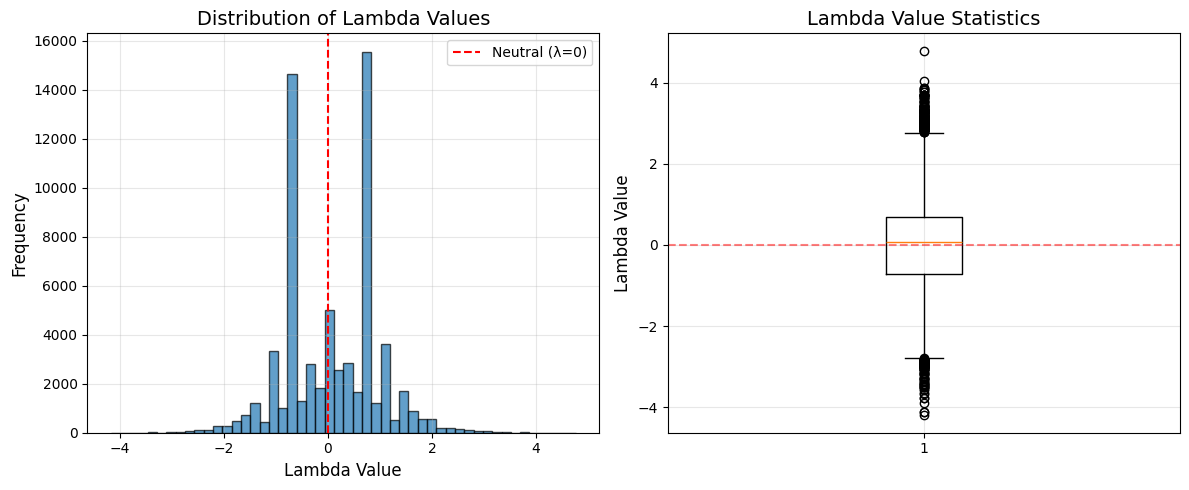

Lambda Statistics:
  Mean: 0.060
  Median: 0.063
  Std Dev: 0.899
  Max (most positive): 4.768
  Min (most negative): -4.178


In [30]:
import matplotlib.pyplot as plt

def plot_lambda_distribution(lambda_dict):
    """Plot histogram of lambda values"""
    lambdas = list(lambda_dict.values())

    plt.figure(figsize=(12, 5))

    # Histogram
    plt.subplot(1, 2, 1)
    plt.hist(lambdas, bins=50, edgecolor='black', alpha=0.7)
    plt.xlabel('Lambda Value', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title('Distribution of Lambda Values', fontsize=14)
    plt.axvline(x=0, color='r', linestyle='--', label='Neutral (λ=0)')
    plt.legend()
    plt.grid(alpha=0.3)

    # Box plot
    plt.subplot(1, 2, 2)
    plt.boxplot(lambdas, vert=True)
    plt.ylabel('Lambda Value', fontsize=12)
    plt.title('Lambda Value Statistics', fontsize=14)
    plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Statistics
    print(f"Lambda Statistics:")
    print(f"  Mean: {np.mean(lambdas):.3f}")
    print(f"  Median: {np.median(lambdas):.3f}")
    print(f"  Std Dev: {np.std(lambdas):.3f}")
    print(f"  Max (most positive): {np.max(lambdas):.3f}")
    print(f"  Min (most negative): {np.min(lambdas):.3f}")

plot_lambda_distribution(lambda_dict)


### Challenge 7.3: Handle Imbalanced Datasets

**Experiment**: Train on imbalanced data

```python
# Create imbalanced dataset: 70% positive, 30% negative
pos_count = int(len(train_reviews) * 0.7)
neg_count = len(train_reviews) - pos_count

# Subsample to create imbalance
# ... your code here ...

# Train and compare
lambda_dict_imb, log_prior_imb, stats_imb = train_naive_bayes(
    imbalanced_reviews, imbalanced_labels
)

print(f"Balanced log_prior: {log_prior:.3f}")
print(f"Imbalanced log_prior: {log_prior_imb:.3f}")
print(f"Difference: {log_prior_imb - log_prior:.3f}")
```

**Questions:**

1. How does log_prior change?
2. How does accuracy on balanced test set change?
3. How does accuracy on imbalanced test set change?
4. Why does Naive Bayes handle imbalance naturally?

---

## Submission Checklist

### Code Implementation

- [ ] `count_words(reviews, labels)` - Frequency counting
- [ ] `get_class_stats(freqs)` - Class statistics
- [ ] `get_word_probability(word, label, freqs, stats)` - Conditional probability
- [ ] `calculate_lambda(word, freqs, stats)` - Log likelihood ratio
- [ ] `train_naive_bayes(reviews, labels)` - Complete training
- [ ] `naive_bayes_predict(review, lambda_dict, log_prior, stats)` - Prediction
- [ ] `test_naive_bayes(reviews, labels, ...)` - Batch evaluation
- [ ] `get_top_words(lambda_dict, n)` - Analysis function

### Testing & Validation

- [ ] All unit tests pass
- [ ] Training completes in < 5 seconds
- [ ] Test accuracy > 75%
- [ ] Log prior calculated correctly
- [ ] Unknown words handled gracefully
- [ ] No division by zero errors

### Analysis

- [ ] Error analysis completed
- [ ] Top positive/negative words identified
- [ ] Comparison with Week 1 logistic regression
- [ ] Understanding of failure patterns
- [ ] Insights about naive independence assumption

### Documentation

- [ ] Comments explaining probability calculations
- [ ] Docstrings for all functions
- [ ] Answers to reflection questions
- [ ] Comparison table with logistic regression

---


## Reflection Questions

Answer these to deepen understanding:

1. **Probability fundamentals**: Explain Laplacian smoothing in your own words. Why is the +1 in the numerator and +V in the denominator?

2. **Log likelihood**: Why do we use log(P(pos)/P(neg)) instead of just P(pos)/P(neg)? What problems does this solve?

3. **Independence assumption**: Give 3 examples from your test set where the naive independence assumption clearly fails. Why does the model still work reasonably well despite this?

4. **Comparison with Week 1**:

   - Which model trains faster? By how much?
   - Which model is more interpretable?
   - Which model handles unknown words better?
   - When would you choose Naive Bayes? When would you choose Logistic Regression?

5. **Log prior**: You have a dataset with 1200 positive and 800 negative reviews. Calculate log_prior by hand. How much does this bias predictions toward positive?

6. **Vocabulary size**: Your model has V=5000 unique words. A new word appears in test data. What probability does Naive Bayes assign to it? Show calculation.

7. **Error patterns**: Looking at your misclassified examples, what are the top 3 failure modes? How would you improve the model to handle these?

8. **Feature representation**: Compare the features used by Logistic Regression vs Naive Bayes:

   - LR: [1, sum_pos, sum_neg] - 3 features
   - NB: Individual word presence - 5000+ features
     Which is more expressive? Which is more efficient?

9. **Smoothing impact**: What would happen if you used α=0 (no smoothing)? What about α=10 (heavy smoothing)?

10. **Real-world application**: You need to build a spam filter that processes 1 million emails per day. Would you use Naive Bayes or Logistic Regression? Justify your choice considering:
    - Training time on 100k labeled emails
    - Prediction speed requirements
    - Model interpretability for explaining to users
    - Handling of new spam patterns (unknown words)

---


## Success Criteria

You've mastered Week 2 when:

1. ✅ Model trains in < 5 seconds (vs 30+ for logistic regression)
2. ✅ Test accuracy between 78-86%
3. ✅ Can calculate probabilities with Laplacian smoothing by hand
4. ✅ Can explain why log likelihood prevents underflow
5. ✅ Understand the naive independence assumption and its violations
6. ✅ Can identify and explain error patterns
7. ✅ Can compare strengths/weaknesses with logistic regression
8. ✅ Have working code with no numpy warnings/errors

---


## Key Takeaways

### Mathematical Foundations

- **Bayes' Rule**: P(class|words) ∝ P(words|class) × P(class)
- **Laplacian Smoothing**: Prevents zero probabilities
- **Log Likelihood**: Prevents numerical underflow
- **Log Prior**: Handles class imbalance

### Practical Insights

1. **Speed**: Naive Bayes is 10-100x faster to train
2. **Simplicity**: No hyperparameters, no tuning
3. **Interpretability**: Can see exactly which words matter
4. **Robustness**: Handles unknown words gracefully

### Limitations

1. **Independence assumption**: Words clearly depend on each other
2. **Word order**: "not good" = "good not" to the model
3. **Context**: Can't understand sarcasm or negation
4. **Mixed sentiment**: Treats each word independently

### When to Use Naive Bayes

- Fast training required
- Large vocabulary
- Limited training data
- Baseline model needed
- Interpretability important

### When to Use Logistic Regression (Week 1)

-  More training time available
-  Better generalization needed
-  Capturing word combinations
-  Higher accuracy required
---


## Next Steps

You're now ready for **Week 3: Vector Space Models**!

In Week 3, you'll learn about:

- Word embeddings and vector representations
- Cosine similarity between word vectors
- Principal Component Analysis (PCA)
- Word analogies and semantic relationships

**The progression**:

- Week 1: Numerical features from text (logistic regression)
- Week 2: Probabilistic reasoning (Naive Bayes)
- **Week 3: Semantic vector spaces (word embeddings)**
- Week 4: Machine translation and hashing

---


## Getting Help

### Common Issues

**"My lambda values are all zero"**

- Check that you're calculating conditional probabilities correctly
- Verify Laplacian smoothing is applied
- Print intermediate values to debug

**"I get division by zero"**

- Laplacian smoothing should prevent this
- Check that N_class + V is never zero
- Verify you're using .get() for dictionary access

**"Training is too slow"**

- Should be < 5 seconds for 2000 reviews
- Avoid nested loops where possible
- Use dictionary operations efficiently
- Don't recalculate statistics repeatedly

**"Accuracy is too low (< 75%)"**

- Check preprocessing is working correctly
- Verify lambda calculations
- Ensure log_prior is calculated
- Compare with manual calculations on small examples

**"Unknown words crash my code"**

- Use `lambda_dict.get(word, 0)` not `lambda_dict[word]`
- Handle gracefully by treating as neutral
- Or calculate on-the-fly with Laplacian smoothing

---


## Pro Tips

1. **Start small**: Test with 10 reviews before using all 2000
2. **Print everything**: Debug by printing intermediate probabilities
3. **Manual calculation**: Do one example by hand to verify code
4. **Compare with Week 1**: Different approach, similar results
5. **Enjoy the speed**: Notice how fast Naive Bayes trains!

---

**Congratulations on completing Week 2!**

You now understand two fundamentally different approaches to NLP classification:

- **Week 1**: Optimization-based (gradient descent)
- **Week 2**: Counting-based (frequency and probability)

Both have their place in modern NLP. Naive Bayes remains popular for:

- Spam filtering
- Document classification
- Real-time applications
- Baseline models
- Resource-constrained environments

**You're building a strong foundation in NLP! Keep going!**

**Congratulations on completing Week 2!**

You now understand two fundamentally different approaches to NLP classification.